In [1]:
import sys
dir_git = "/Users/usuario/git/sisepuede"
if dir_git not in sys.path:
    sys.path.append(dir_git)


import importlib
import matplotlib.pyplot as plt
import numpy as np
import os, os.path
import pandas as pd
import pathlib
import sisepuede.core.support_classes as sc
import sisepuede.manager.sisepuede_file_structure as sfs
import sisepuede.manager.sisepuede_models as sm
import sisepuede.utilities.data_support._elasticities as elast
import sisepuede.utilities._toolbox as sf
import utils.common_data_needs as cdn
import warnings
warnings.filterwarnings("ignore")

from typing import *

plt.style.use("dark_background", )



/Users/usuario/git/sisepuede/sisepuede/utilities/_toolbox.py:533: UserWarning: Path '/Users/usuario/git/sisepuede/sisepuede/out/sisepuede_run_2025-09-26T22;57;22.779815' not found. It will not be created.
  warnings.warn(msg)
/Users/usuario/git/sisepuede/sisepuede/core/model_attributes.py:6827: UserWarning: 

                        MISSIONSEARCHNOTE: As of 2023-10-06, there is a temporary solution 
                        implemeted in ModelAttributes.get_variable_to_simplex_group_dictionary() 
                        to ensure that transition probability rows are enforced on a simplex.
                        
                        
                        FIX THIS ASAP TO DERIVE PROPERLY.
                        
                        
  warnings.warn(
/Users/usuario/git/sisepuede/sisepuede/utilities/_toolbox.py:533: UserWarning: Path '/Users/usuario/git/sisepuede/sisepuede/out/sisepuede_run_2025-09-26T22;57;23.123588' not found. It will not be created.
  warnings.warn(msg)
/Use

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


Precompiling NemoMod...
Info Given NemoMod was explicitly requested, output will be shown live 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
   1342.2 ms  ? NemoMod
[ Info: Precompiling NemoMod [a3c327a0-d2f0-11e8-37fd-d12fd35c3c72] 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Info: Skipping precompilation due to precompilable error. Importing NemoMod [a3c327a0-d2f0-11e8-37fd-d12fd35c3c72].
└   exception = Error when precompiling module, potentially caused by a __precompile__(false) declaration in the module.
/Users/usuario/git/sisepuede/sisepuede/utilities/_toolbox.py:2622: UserWarning: Warning passed from optional_log: Successfully initialized JuMP optimizer from solver module HiGHS..
  warnings.warn(f"Warning passed from optional_log: {msg}.")


# Initialize some SISEPUEDE components

In [2]:
dict_ssp = cdn._setup_sisepuede_elements()

matt = dict_ssp.get("model_attributes", )
models = dict_ssp.get("models", )
regions = dict_ssp.get("regions", )
time_periods = dict_ssp.get("time_periods", )

# setup region
_REGION_NAME = "uganda"
_REGION_ISO = regions.return_region_or_iso(_REGION_NAME, return_type = "iso")

# set year of survey data
_YEAR_SURVEY = 2021
_YEAR_TARGET = 2100
_DF_YEARS = cdn.spawn_years_space_df((2015, _YEAR_TARGET + 1))


##################################################
#    initialize a global dict for populations    #
##################################################

_ATTRIBUTE_TABLE_LVST = matt.get_attribute_table(matt.subsec_name_lvst, )


##  Set some model variables

In [151]:
_MODVAR_DEMAND = matt.get_variable("Livestock Demand")
_MODVAR_GDP = matt.get_variable(models.model_afolu.model_socioeconomic.modvar_econ_gdp, )
_MODVAR_GDP_PER_CAPITA = matt.get_variable("GDP per Capita")
_MODVAR_DUMMY_SCALAR = matt.get_variable(models.model_afolu.modvar_lvst_frac_demand_imported, )
_MODVAR_ELASTICITES = matt.get_variable(models.model_afolu.modvar_lvst_elas_lvst_demand, )
_MODVAR_EXPORTS = matt.get_variable(models.model_afolu.modvar_lvst_equivalent_exports, )
_MODVAR_POP = matt.get_variable(models.model_afolu.modvar_lvst_pop, )
_MODVAR_POP_INIT = matt.get_variable(models.model_afolu.modvar_lvst_pop_init, )

# derivative export file
_FN_EXPORT = cdn.file_name_from_variable(_MODVAR_ELASTICITES, )

In [ ]:
_MODVAR_EXPORTS.get_from_dataframe(df_inputs)

In [166]:
# build base input
df_inputs = cdn._build_from_outputs(
    (
        min(time_periods.all_years), 
        max(time_periods.all_years)
    ),
    fns_exclude = [
        _FN_EXPORT
    ],
    force_complete_build = True, 
    merge_type = "outer", 
    print_info = False,
    stop_on_error = True, 
)
df_inputs = time_periods.tps_to_years(
    df_inputs,
)


##  MODIFY DEMAND BY REMOVING EXPORTS

# update df to remove exports
arr_demand = _MODVAR_POP_INIT.get_from_dataframe(
    df_inputs,
    expand_to_all_categories = True, 
    return_type = "array"
)

arr_exports = _MODVAR_EXPORTS.get_from_dataframe(
    df_inputs,
    expand_to_all_categories = True, 
    return_type = "array"
)

arr_demand_adj = sf.vec_bounds(arr_demand - arr_exports, (0, np.inf))

# update
df_inputs[_MODVAR_POP_INIT.fields] = matt.array_to_df(
    arr_demand_adj,
    _MODVAR_POP_INIT,
    reduce_from_all_cats_to_specified_cats = True,
)





<Axes: >

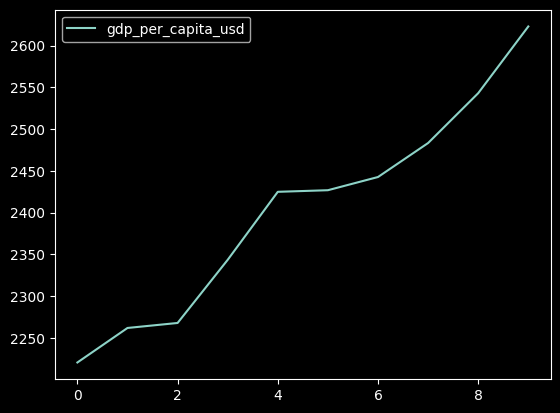

In [167]:
_MODVAR_GDP_PER_CAPITA.get_from_dataframe(df_proj).iloc[0:10].plot()

<Axes: >

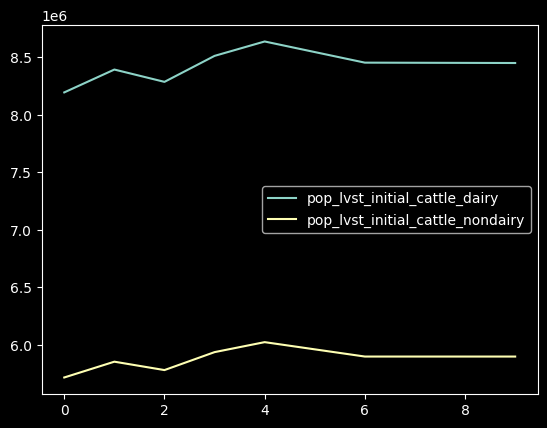

In [168]:
_MODVAR_POP_INIT.get_from_dataframe(df_proj).iloc[0:10, 1:3].plot()

In [169]:
# project socioeconomic so that GDP/Capita can be used as a driver
df_proj = models.model_socioeconomic(df_inputs)[0]
df_proj[_MODVAR_DUMMY_SCALAR.fields] = 1

time_period_project_first = 6

df_prodscalar, df_elasticities, df_prodinit = elast.exogenous_demands_to_sispeuede_ies(
    df_proj,
    matt,
    _MODVAR_POP_INIT,                        # model_ippu.modvar_ippu_prod_qty_init,
    _MODVAR_GDP_PER_CAPITA,                  # model_ippu.model_socioeconomic.modvar_econ_gdp,
    _MODVAR_ELASTICITES,                     # model_ippu.modvar_ippu_elast_ind_prod_to_gdp,
    _MODVAR_DUMMY_SCALAR,                    # model_ippu.modvar_ippu_scalar_production,
    time_period_project_first,
    elasticity_bounds = (-0.5, 0.5),
    elasticity_default = 0.5,
    field_iso = regions.field_iso,
    max_dev_from_mean = 0.2,
    #sup_elast_magnitude = 1,
    stop_on_error = True,
)

<Axes: >

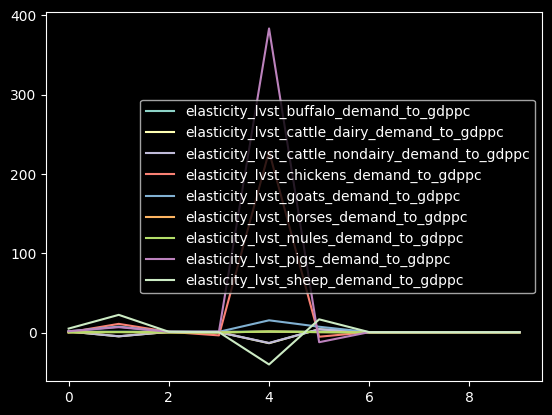

In [170]:
df_elasticities.drop(columns = ["year"]).iloc[0:10].plot()

In [171]:
#_MODVAR_ELASTICITES.get_from_dataframe(df_inputs)
modvar_area = matt.get_variable("Land Use Area")
modvar_area.get_from_dataframe(df_test_proj, )






,area_lndu_croplands,area_lndu_flooded,area_lndu_forests_mangroves,area_lndu_forests_primary,area_lndu_forests_secondary,area_lndu_grasslands,area_lndu_other,area_lndu_pastures,area_lndu_settlements,area_lndu_shrublands,area_lndu_wetlands
0,1.049614e+07,3.737645e+06,0.0,286996.746396,1.690335e+06,3.764559e+06,13543.943118,1.357987e+06,129395.701790,1.964078e+06,7.143155e+05
1,1.053998e+07,3.716337e+06,0.0,282715.031619,1.696216e+06,3.738325e+06,13609.351061,1.335676e+06,127909.477104,1.934656e+06,7.695783e+05
2,1.060490e+07,3.716330e+06,0.0,278685.643755,1.729252e+06,3.731294e+06,14884.487688,1.337048e+06,127002.161674,1.771646e+06,8.439603e+05
3,1.067849e+07,3.696191e+06,0.0,274544.510805,2.112792e+06,3.890383e+06,15114.344301,1.387645e+06,181304.862228,1.071033e+06,8.475023e+05
4,1.073105e+07,3.656784e+06,0.0,270428.215896,2.475678e+06,4.047090e+06,15117.830889,1.423104e+06,217395.137608,4.870019e+05,8.313544e+05
5,1.081835e+07,3.630181e+06,0.0,267379.962747,2.483239e+06,3.853405e+06,15126.144434,1.567619e+06,215548.977283,4.460700e+05,8.580796e+05
6,1.086298e+07,3.615504e+06,0.0,263480.024491,2.469073e+06,3.859471e+06,15876.318942,1.510994e+06,213437.215418,4.242138e+05,9.199700e+05
7,1.090617e+07,3.601306e+06,0.0,259636.969774,2.454748e+06,3.854095e+06,16680.601054,1.467566e+06,211344.376784,4.034415e+05,9.800162e+05
8,1.094802e+07,3.587574e+06,0.0,255849.968905,2.440299e+06,3.840762e+06,17537.378479,1.433673e+06,209271.226823,3.836991e+05,1.038320e+06
9,1.098862e+07,3.574293e+06,0.0,252118.247860,2.424716e+06,3.821964e+06,18450.316075,1.406686e+06,207218.255545,3.669822e+05,1.093952e+06


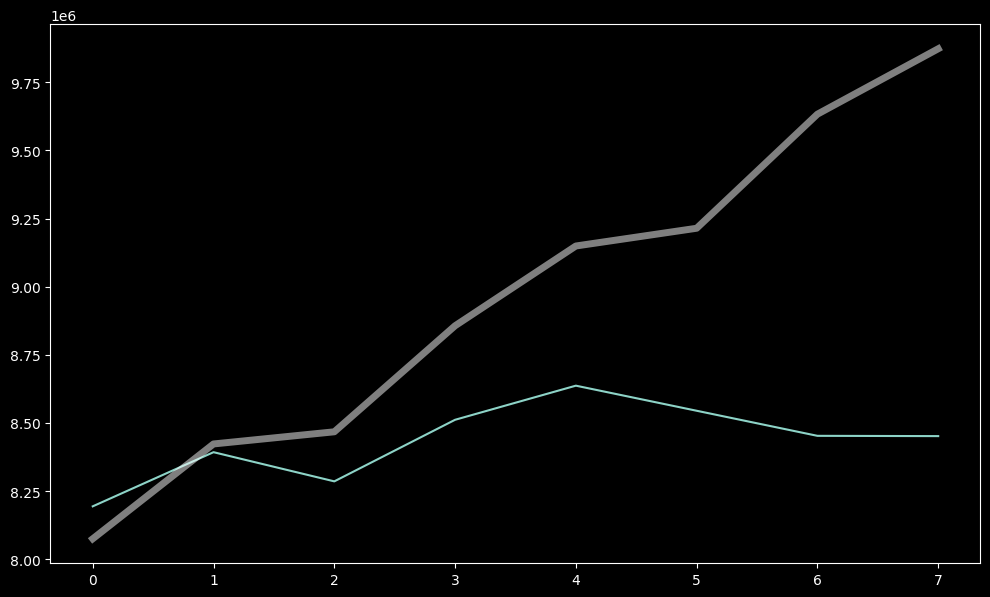

In [172]:
df_test = sf.match_df_to_target_df(
    df_inputs,
    df_elasticities,
    [
        time_periods.field_year,
        regions.field_iso,
    ]
)


df_test_proj = models.model_afolu(df_test, )


##  COMPARISON PLOT

fig, ax = plt.subplots(figsize = (12, 7))

_CAT_LVST = "cattle_dairy"
field_init = _MODVAR_POP_INIT.build_fields(category_restrictions = _CAT_LVST, )
field_proj = _MODVAR_DEMAND.build_fields(category_restrictions = _CAT_LVST, )

ax.plot(df_test[field_init].iloc[0:8], label = "base", )
ax.plot(df_test_proj[field_proj].iloc[0:8], alpha = 0.5, color = "white", linewidth = 5, label = "projected", )



# Export

In [173]:
df_elasticities.to_csv(
    cdn._PATH_OUTPUTS.joinpath(_FN_EXPORT, ),
    encoding = "UTF-8",
    index = None,
)
